In [1]:
%pip install -r ../test_requirements.txt



Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install albumentations


  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-macosx_12_0_x86_64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.10.0.84-cp37-abi3-macosx_12_0_x86_64.whl (56.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip uninstall opencv-python-headless opencv-python opencv-contrib-python -y
%pip install opencv-python


Found existing installation: opencv-python-headless 4.10.0.84
Uninstalling opencv-python-headless-4.10.0.84:
  Successfully uninstalled opencv-python-headless-4.10.0.84
Found existing installation: opencv-python 4.10.0.84
Uninstalling opencv-python-4.10.0.84:
  Successfully uninstalled opencv-python-4.10.0.84
Note: you may need to restart the kernel to use updated packages.
  Using cached opencv_python-4.10.0.84-cp37-abi3-macosx_12_0_x86_64.whl.metadata (20 kB)
Using cached opencv_python-4.10.0.84-cp37-abi3-macosx_12_0_x86_64.whl (56.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import albumentations as A
import json

# Import custom configurations
from config import (
    GLOBAL_CONFIG_DATA_PATH,
    GLOBAL_CONFIG_DATA_RAW_IMAGE_PATH,
    GLOBAL_CONFIG_DATA_RAW_LABEL_PATH,
    GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH,
    GLOBAL_CONFIG_RESULT_PATH,
    GLOBAL_CONFIG_DATA_RAW_COMPTEST_PATH,
    PROCESSED_LABEL_PATH
)

# Print the current working directory to confirm where your script is running
print("Current Working Directory:", os.getcwd())


/Users/frankoswanepoel/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Data path: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data
Raw images path: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/raw/images
Labels path: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/Train.csv
CompTest path: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/Test.csv
Results path: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/results
Processed images path: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/processed
Processed labels path: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/augmented_labels.csv
Current Working Directory: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/notebooks


In [5]:
# List and count raw images
try:
    raw_images = os.listdir(GLOBAL_CONFIG_DATA_RAW_IMAGE_PATH)
    print(f"Number of raw images: {len(raw_images)}")
except FileNotFoundError:
    print(f"Error: The directory {GLOBAL_CONFIG_DATA_RAW_IMAGE_PATH} does not exist.")


Number of raw images: 3926


In [6]:
# Define a path to store the max dimensions
max_dim_file = "max_dimensions.json"

# Check if max dimensions have already been calculated
if os.path.exists(max_dim_file):
    with open(max_dim_file, "r") as file:
        max_dims = json.load(file)
        max_width, max_height = max_dims["max_width"], max_dims["max_height"]
    print(f"Loaded max dimensions from file: Maximum width: {max_width}, Maximum height: {max_height}")
else:
    # Initialize maximum dimensions
    max_width = 0
    max_height = 0

    # Find the maximum width and height among all images
    for image_name in tqdm(os.listdir(GLOBAL_CONFIG_DATA_RAW_IMAGE_PATH), desc="Finding max dimensions"):
        image_path = os.path.join(GLOBAL_CONFIG_DATA_RAW_IMAGE_PATH, image_name)
        img = cv2.imread(image_path)
        if img is None:
            print(f"Failed to load image: {image_path}")
            continue
        h, w = img.shape[:2]
        max_width = max(max_width, w)
        max_height = max(max_height, h)

    print(f"Calculated maximum width: {max_width}, Maximum height: {max_height}")

    # Save the max dimensions to a JSON file
    with open(max_dim_file, "w") as file:
        json.dump({"max_width": max_width, "max_height": max_height}, file)


Loaded max dimensions from file: Maximum width: 4160, Maximum height: 3120


In [7]:
def preprocess_image(image_path, max_width, max_height):
    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Failed to load image: {image_path}")
        return None, 0, 0
    # Convert to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Remove non-cell parts (black areas)
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([50, 50, 50])
    mask_black = cv2.inRange(img_rgb, lower_black, upper_black)
    img_rgb[mask_black == 255] = [255, 255, 255]

    h, w = img_rgb.shape[:2]
    pad_right = max_width - w
    pad_top = max_height - h

    if pad_right < 0 or pad_top < 0:
        print(f"Image {image_path} is larger than max dimensions.")
        return None, 0, 0

    # Pad the image on the right and top sides
    img_padded = cv2.copyMakeBorder(
        img_rgb,
        top=pad_top,
        bottom=0,
        left=0,
        right=pad_right,
        borderType=cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )

    # Normalize pixel values (0 to 1)
    img_normalized = img_padded / 255.0

    return img_normalized, pad_top, pad_right


In [8]:
# Ensure the processed images directory exists
if not os.path.exists(GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH):
    os.makedirs(GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH)

# Path for the padding information file
padding_info_file = os.path.join(GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH, 'padding_info.json')

# Check if padding info has already been saved
if os.path.exists(padding_info_file):
    with open(padding_info_file, "r") as file:
        padding_dict = json.load(file)
    print("Loaded padding information from file.")
else:
    # Initialize an empty dictionary for padding info
    padding_dict = {}

    # List of raw images
    raw_images = [f for f in os.listdir(GLOBAL_CONFIG_DATA_RAW_IMAGE_PATH) if not f.startswith('.')]

    # Process and save all images
    for image_name in tqdm(raw_images, desc="Processing images"):
        image_path = os.path.join(GLOBAL_CONFIG_DATA_RAW_IMAGE_PATH, image_name)
        
        # Preprocess image
        processed_image, pad_top, pad_right = preprocess_image(image_path, max_width, max_height)

        if processed_image is not None:
            # Convert back to uint8 for saving
            processed_image_uint8 = (processed_image * 255).astype(np.uint8)
            # Save processed image
            save_path = os.path.join(GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH, image_name)
            cv2.imwrite(save_path, cv2.cvtColor(processed_image_uint8, cv2.COLOR_RGB2BGR))
            # Save the padding information
            padding_dict[image_name] = {'pad_top': pad_top, 'pad_right': pad_right}

    # Save padding information to a JSON file
    with open(padding_info_file, "w") as file:
        json.dump(padding_dict, file, indent=4)
    print("Padding information saved.")


Loaded padding information from file.


In [9]:
from config import GLOBAL_CONFIG_DATA_RAW_LABEL_PATH

# Path to save adjusted labels
adjusted_labels_path = os.path.join(GLOBAL_CONFIG_DATA_PATH, "adjusted_labels.csv")

# Check if adjusted labels already exist
if os.path.exists(adjusted_labels_path):
    train_labels = pd.read_csv(adjusted_labels_path)
    print(f"Loaded adjusted labels from {adjusted_labels_path}")
else:
    # Load the training labels
    train_labels = pd.read_csv(GLOBAL_CONFIG_DATA_RAW_LABEL_PATH)

    # Initialize new columns for adjusted bounding boxes
    train_labels['new_xmin'] = train_labels['xmin']
    train_labels['new_ymin'] = train_labels['ymin']
    train_labels['new_xmax'] = train_labels['xmax']
    train_labels['new_ymax'] = train_labels['ymax']

    # Adjust bounding boxes based on padding
    for idx, row in train_labels.iterrows():
        image_name = row['Image_ID']
        if image_name in padding_dict:
            pad_top = padding_dict[image_name]['pad_top']
            pad_right = padding_dict[image_name]['pad_right']
            # Adjust coordinates
            train_labels.at[idx, 'new_xmin'] = row['xmin']
            train_labels.at[idx, 'new_xmax'] = row['xmax']
            train_labels.at[idx, 'new_ymin'] = row['ymin'] + pad_top
            train_labels.at[idx, 'new_ymax'] = row['ymax'] + pad_top

    # Update the DataFrame with adjusted bounding boxes
    train_labels['xmin'] = train_labels['new_xmin']
    train_labels['xmax'] = train_labels['new_xmax']
    train_labels['ymin'] = train_labels['new_ymin']
    train_labels['ymax'] = train_labels['new_ymax']
    train_labels = train_labels.drop(columns=['new_xmin', 'new_ymin', 'new_xmax', 'new_ymax'])

    # Save adjusted labels
    train_labels.to_csv(adjusted_labels_path, index=False)
    print(f"Adjusted labels saved to {adjusted_labels_path}")


Loaded adjusted labels from /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/adjusted_labels.csv


In [10]:
# Load the adjusted labels
train_labels = pd.read_csv(adjusted_labels_path)

# Display first few rows
print(train_labels.head())

# Get unique classes
unique_classes = train_labels['class'].unique()
print(f"Unique classes: {unique_classes}")

# Calculate class counts
class_counts = train_labels['class'].value_counts()
print("Class distribution:")
print(class_counts)


            Image_ID        class  confidence  ymin  xmin  ymax  xmax
0  id_u3q6jdck4j.jpg  Trophozoite         1.0  2752  1241  2777  1270
1  id_a6cl90trri.jpg  Trophozoite         1.0  2598  1566  2640  1604
2  id_qvc2le9sm8.jpg  Trophozoite         1.0  1317  2788  1448  2914
3  id_w8xnbd5rvm.jpg  Trophozoite         1.0  1029  1744  1145  1823
4  id_6dop09rk02.jpg          NEG         1.0   120     0   120     0
Unique classes: ['Trophozoite' 'NEG' 'WBC']
Class distribution:
class
Trophozoite    15838
WBC             7004
NEG              688
Name: count, dtype: int64


In [11]:
# Define augmentation pipeline with Albumentations
transform = A.Compose(
    [
        A.Rotate(limit=90, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomScale(scale_limit=0.1, p=0.5),
    ],
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])
)


In [12]:
# Path to save augmented labels
augmented_labels_path = os.path.join(GLOBAL_CONFIG_DATA_PATH, "augmented_labels.csv")

# Check if augmented labels already exist
if os.path.exists(augmented_labels_path):
    augmented_df = pd.read_csv(augmented_labels_path)
    print(f"Loaded augmented labels from {augmented_labels_path}")
else:
    # Ensure the processed images directory exists
    if not os.path.exists(GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH):
        os.makedirs(GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH)

    # Group labels by 'Image_ID'
    grouped = train_labels.groupby('Image_ID')

    new_rows = []
    for image_name, group in tqdm(grouped, desc="Augmenting images"):
        image_path = os.path.join(GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH, image_name)
        img = cv2.imread(image_path)
        if img is None:
            print(f"Failed to load image: {image_path}")
            continue

        h, w = img.shape[:2]

        # Collect bounding boxes and labels
        bboxes = []
        class_labels = []
        for idx, row in group.iterrows():
            xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
            class_label = row['class']
            # Only include valid bounding boxes
            if xmin < xmax and ymin < ymax:
                xmin = max(0, min(w, xmin))
                xmax = max(0, min(w, xmax))
                ymin = max(0, min(h, ymin))
                ymax = max(0, min(h, ymax))
                bboxes.append([xmin, ymin, xmax, ymax])
                class_labels.append(class_label)
            else:
                print(f"Invalid bounding box in image {image_name}, skipping bbox with index {idx}")

        # Apply augmentation only if there are valid bounding boxes
        if len(bboxes) > 0:
            try:
                augmented = transform(image=img, bboxes=bboxes, class_labels=class_labels)
            except Exception as e:
                print(f"Skipping augmentation for {image_name} due to error: {e}")
                continue

            # Save augmented image
            aug_image_name = f'aug_{image_name}'
            aug_image_path = os.path.join(GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH, aug_image_name)
            cv2.imwrite(aug_image_path, augmented['image'])

            # Save augmented bounding boxes
            for bbox, cls in zip(augmented['bboxes'], augmented['class_labels']):
                new_row = {
                    'Image_ID': aug_image_name,
                    'xmin': int(bbox[0]),
                    'ymin': int(bbox[1]),
                    'xmax': int(bbox[2]),
                    'ymax': int(bbox[3]),
                    'class': cls,
                    'confidence': row.get('confidence', 1.0),  # Use existing confidence or default to 1.0
                    'augmented': True
                }
                new_rows.append(new_row)
        else:
            # Handle images without bounding boxes (e.g., 'NEG' class)
            aug_image_name = f'aug_{image_name}'
            aug_image_path = os.path.join(GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH, aug_image_name)
            cv2.imwrite(aug_image_path, img)  # Save original image without augmentation
            new_row = {
                'Image_ID': aug_image_name,
                'xmin': 0,
                'ymin': 0,
                'xmax': 0,
                'ymax': 0,
                'class': group.iloc[0]['class'],  # Assuming all rows have the same class
                'confidence': group.iloc[0].get('confidence', 1.0),
                'augmented': True
            }
            new_rows.append(new_row)

    # Create augmented DataFrame
    augmented_df = pd.DataFrame(new_rows)

    # Combine original and augmented data
    combined_df = pd.concat([train_labels, augmented_df], ignore_index=True)

    # Save augmented labels
    combined_df.to_csv(augmented_labels_path, index=False)
    print(f"Augmented labels saved to {augmented_labels_path}")


Loaded augmented labels from /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/augmented_labels.csv


            Image_ID        class  confidence  ymin  xmin  ymax  xmax  \
0  id_u3q6jdck4j.jpg  Trophozoite         1.0  2752  1241  2777  1270   
1  id_a6cl90trri.jpg  Trophozoite         1.0  2598  1566  2640  1604   
2  id_qvc2le9sm8.jpg  Trophozoite         1.0  1317  2788  1448  2914   
3  id_w8xnbd5rvm.jpg  Trophozoite         1.0  1029  1744  1145  1823   
4  id_6dop09rk02.jpg          NEG         1.0   120     0   120     0   

  augmented  
0       NaN  
1       NaN  
2       NaN  
3       NaN  
4       NaN  
Unique classes: ['Trophozoite' 'NEG' 'WBC']
Class distribution after augmentation:
class
Trophozoite    15839
WBC             7004
NEG             1376
Name: count, dtype: int64


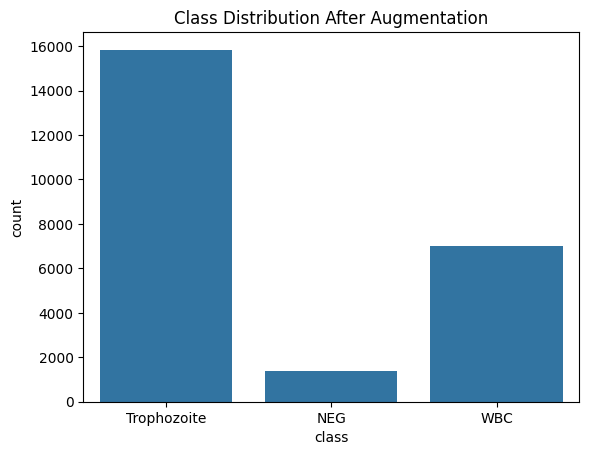

In [13]:
# Load the augmented labels
augmented_labels = pd.read_csv(augmented_labels_path)

# Display first few rows
print(augmented_labels.head())

# Get unique classes
unique_classes = augmented_labels['class'].unique()
print(f"Unique classes: {unique_classes}")

# Calculate class counts
class_counts = augmented_labels['class'].value_counts()
print("Class distribution after augmentation:")
print(class_counts)

# Plot the class distribution
import seaborn as sns

sns.countplot(x='class', data=augmented_labels)
plt.title('Class Distribution After Augmentation')
plt.show()


In [18]:
from tqdm.auto import tqdm  # This version of tqdm automatically handles Jupyter notebooks
import numpy as np

# Path to save balanced labels
balanced_labels_path = os.path.join(GLOBAL_CONFIG_DATA_PATH, "balanced_labels.csv")

# Check if balanced labels already exist
if os.path.exists(balanced_labels_path):
    balanced_df = pd.read_csv(balanced_labels_path)
    print(f"Loaded balanced labels from {balanced_labels_path}")
else:
    # Calculate the maximum number of samples in any class
    class_counts = augmented_labels['class'].value_counts()
    max_count = class_counts.max()

    # Function to augment data for a specific class
    def augment_class(class_name, num_augments):
        class_group = augmented_labels[augmented_labels['class'] == class_name]
        new_rows = []
        images_needed = num_augments - len(class_group)
        images_to_augment = class_group.sample(n=images_needed, replace=True).reset_index(drop=True)

        # Use tqdm to show progress on the augmentation for each class
        for idx, row in tqdm(images_to_augment.iterrows(), total=images_to_augment.shape[0], desc=f"Augmenting class {class_name}"):
            image_name = row['Image_ID']
            image_path = os.path.join(GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH, image_name)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image: {image_path}")
                continue

            h, w = img.shape[:2]
            class_label = row['class']

            # Check if the image has bounding boxes
            has_bbox = not (
                pd.isna(row['xmin']) or pd.isna(row['ymin']) or pd.isna(row['xmax']) or pd.isna(row['ymax'])
                or (row['xmin'] == 0 and row['ymin'] == 0 and row['xmax'] == 0 and row['ymax'] == 0)
            )

            if has_bbox and class_label != 'NEG':
                # Get bounding box coordinates
                xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']

                # Convert normalized bounding boxes to absolute coordinates if necessary
                if xmin <= 1 and xmax <= 1 and ymin <= 1 and ymax <= 1:
                    # Assuming bounding boxes are normalized, convert to absolute coordinates
                    xmin = int(xmin * w)
                    xmax = int(xmax * w)
                    ymin = int(ymin * h)
                    ymax = int(ymax * h)
                else:
                    # Ensure coordinates are integers
                    xmin = int(xmin)
                    xmax = int(xmax)
                    ymin = int(ymin)
                    ymax = int(ymax)

                # Ensure bounding boxes are within image boundaries
                xmin = max(0, min(w - 1, xmin))
                xmax = max(0, min(w - 1, xmax))
                ymin = max(0, min(h - 1, ymin))
                ymax = max(0, min(h - 1, ymax))

                # Skip invalid bounding boxes
                if xmin >= xmax or ymin >= ymax:
                    print(f"Skipping invalid bounding box in image {image_name}")
                    bboxes = []
                    class_labels = []
                else:
                    bboxes = [[xmin, ymin, xmax, ymax]]
                    class_labels = [class_label]
            else:
                # For images without bounding boxes (e.g., 'NEG' class)
                bboxes = []
                class_labels = []

            # Apply augmentation
            try:
                augmented = transform(image=img, bboxes=bboxes, class_labels=class_labels)
            except Exception as e:
                print(f"Skipping augmentation for {image_name} due to error: {e}")
                continue

            # Save augmented image
            aug_image_name = f'bal_aug_{idx}_{image_name}'
            aug_image_path = os.path.join(GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH, aug_image_name)
            cv2.imwrite(aug_image_path, augmented['image'])

            # Save augmented bounding boxes
            if len(augmented['bboxes']) > 0:
                for bbox, cls in zip(augmented['bboxes'], augmented['class_labels']):
                    aug_xmin, aug_ymin, aug_xmax, aug_ymax = bbox
                    new_row = {
                        'Image_ID': aug_image_name,
                        'xmin': int(aug_xmin),
                        'ymin': int(aug_ymin),
                        'xmax': int(aug_xmax),
                        'ymax': int(aug_ymax),
                        'class': cls,
                        'confidence': row.get('confidence', 1.0),
                        'augmented': True
                    }
                    new_rows.append(new_row)
            else:
                # For images without bounding boxes
                new_row = {
                    'Image_ID': aug_image_name,
                    'xmin': np.nan,
                    'ymin': np.nan,
                    'xmax': np.nan,
                    'ymax': np.nan,
                    'class': class_label,
                    'confidence': row.get('confidence', 1.0),
                    'augmented': True
                }
                new_rows.append(new_row)
        return new_rows

    # Augment underrepresented classes
    new_balanced_rows = []
    # Use tqdm to show overall progress on the balancing process
    for class_name, count in tqdm(class_counts.items(), desc="Balancing classes"):
        if count < max_count:
            num_augments = max_count
            print(f"Augmenting class '{class_name}' to have {num_augments} samples.")
            new_rows = augment_class(class_name, num_augments)
            new_balanced_rows.extend(new_rows)

    # Create DataFrame for new augmented samples
    balanced_augmented_df = pd.DataFrame(new_balanced_rows)

    # Combine with existing augmented data
    balanced_df = pd.concat([augmented_labels, balanced_augmented_df], ignore_index=True)

    # Save balanced labels
    balanced_df.to_csv(balanced_labels_path, index=False)
    print(f"Balanced labels saved to {balanced_labels_path}")


Balancing classes: 0it [00:00, ?it/s]

Augmenting class 'WBC' to have 15839 samples.


Augmenting class WBC:   0%|          | 0/8835 [00:00<?, ?it/s]

Failed to load image: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/processed/id_pz9z939k3e.jpg
Failed to load image: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/processed/id_2gp13u7qvy.jpg
Failed to load image: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/processed/id_1up94xy9oo.jpg
Augmenting class 'NEG' to have 15839 samples.


Augmenting class NEG:   0%|          | 0/14463 [00:00<?, ?it/s]

Failed to load image: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/processed/aug_9796_id_83miiqha9f.jpg
Failed to load image: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/processed/aug_20084_id_ntgj9z78es.jpg
Failed to load image: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/processed/id_1ufiozvmyy.jpg
Failed to load image: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/processed/aug_1637_id_qp1fje9iz6.jpg
Failed to load image: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/processed/id_pvnlqw6p53.jpg
Failed to load image: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/processed/aug_8_id_y0me081u0v.jpg
Failed to load image: /Users/frankoswanepoel/Desktop/2024/COS 711/Assingments/Assingment3/COS711_Assingment3/data/

Class distribution after balancing:
class
WBC            16838
Trophozoite    15839
NEG            15824
Name: count, dtype: int64


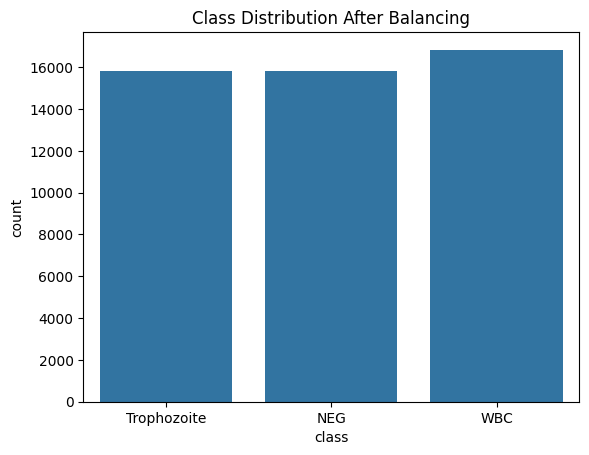

In [19]:
# Load the balanced labels
balanced_labels = pd.read_csv(balanced_labels_path)

# Calculate class counts
balanced_class_counts = balanced_labels['class'].value_counts()
print("Class distribution after balancing:")
print(balanced_class_counts)

# Plot the class distribution
sns.countplot(x='class', data=balanced_labels)
plt.title('Class Distribution After Balancing')
plt.show()
